## 1. Setup and imports
### 1.1 Experiment setup

This notebook tests a small two-client collaborative learning setup across multiple random seeds.

#### Experimental design
- A shared held-out test set is created first.
- The remaining training data is split into two clients.
- Each client receives its own local data stream split into 3 sequential batches.
- A deeper MLP with three weighted layers is used so that the transfer modes are actually different.
- Four strategies are compared:
  - `local_only`
  - `last_layer_only`
  - `last_two_layers`
  - `full_transfer`
- Performance is evaluated on the shared test set after each round.
- Final-round results are compared across seeds.
- Communication cost is approximated by the number of transferred trainable parameters.

#### Why this version was needed
The previous notebook used a model with only two weighted layers, so anything larger than output-only transfer was effectively full transfer. This version fixes that by adding one more weighted layer and introducing a real middle transfer condition.

#### Goal
The goal is not to prove that one method is always best, but to check whether transferring the last two layers can stay close to full transfer while using less communication.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy

# Global experiment settings
N_ROUNDS = 3
EPOCHS = 20
LR = 0.01
TEST_SIZE = 0.2

SEEDS = [37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]

def set_all_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 2. Load and preprocess data

In [2]:
file_path = "../data/data.csv"
df = pd.read_csv(file_path)

print(df.shape)
df.head()

(944, 10)


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [3]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isna().sum())
target_col = "fail"
print(df[target_col].value_counts())

['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
footfall       int64
tempMode       int64
AQ             int64
USS            int64
CS             int64
VOC            int64
RP             int64
IP             int64
Temperature    int64
fail           int64
dtype: object
footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64
fail
0    551
1    393
Name: count, dtype: int64


In [4]:
df_model = df.copy()

# Drop non-feature columns (optional but may be useful for other datasets)
drop_cols = []
for col in df_model.columns:
    if "id" in col.lower():
        drop_cols.append(col)

if drop_cols:
    df_model = df_model.drop(columns=drop_cols)

# Encode binary target if needed
if df_model[target_col].dtype == "object":
    unique_vals = df_model[target_col].unique()
    print("Target values:", unique_vals)
    df_model[target_col] = df_model[target_col].astype("category").cat.codes

df_model.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [5]:
print(df_model[target_col].value_counts())
X = df_model.drop(columns=[target_col])
y = df_model[target_col]
print("X shape:", X.shape)
print("y shape:", y.shape)

fail
0    551
1    393
Name: count, dtype: int64
X shape: (944, 9)
y shape: (944,)


## 3. Updated architecture for deeper partial-transfer experiment

The previous collaborative experiment used an MLP with only two weighted layers
(hidden + output). That created a limitation: any transfer strategy larger than
output-only became effectively full transfer.

To address that bottleneck, this notebook uses a slightly deeper MLP with three
weighted layers:

- `hidden1`
- `hidden2`
- `output`

This makes the following transfer modes genuinely distinct:

- `local_only`
- `last_layer_only`
- `last_two_layers`
- `full_transfer`

The goal of this redesign is not to make the network large, but to create a real
intermediate transfer condition so that the communication/performance trade-off
can be tested more meaningfully.

In [6]:
def prepare_collaborative_data(X, y, seed=42, test_size=0.2, n_rounds=3):
    # Shared test set
    X_train_pool, X_test_shared, y_train_pool, y_test_shared = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=seed
    )

    # Split remaining training pool into two clients
    X_client1, X_client2, y_client1, y_client2 = train_test_split(
        X_train_pool, y_train_pool,
        test_size=0.5,
        stratify=y_train_pool,
        random_state=seed
    )

    client1_batches = split_into_sequential_batches(
        X_client1.reset_index(drop=True),
        y_client1.reset_index(drop=True),
        n_batches=n_rounds
    )

    client2_batches = split_into_sequential_batches(
        X_client2.reset_index(drop=True),
        y_client2.reset_index(drop=True),
        n_batches=n_rounds
    )

    return {
        "X_train_pool": X_train_pool,
        "X_test_shared": X_test_shared,
        "y_test_shared": y_test_shared,
        "client1_batches": client1_batches,
        "client2_batches": client2_batches,
        "X_client1": X_client1,
        "X_client2": X_client2,
        "y_client1": y_client1,
        "y_client2": y_client2,
    }

def split_into_sequential_batches(X_df, y_series, n_batches=3):
    batch_size = len(X_df) // n_batches
    batches = []

    for i in range(n_batches):
        start = i * batch_size
        end = (i + 1) * batch_size if i < n_batches - 1 else len(X_df)

        X_batch = X_df.iloc[start:end].copy()
        y_batch = y_series.iloc[start:end].copy()

        batches.append((X_batch, y_batch))

    return batches

In [7]:
# One example split preview using a single seed
prepared = prepare_collaborative_data(X, y, seed=42, test_size=TEST_SIZE, n_rounds=N_ROUNDS)

print("Shared test set:", prepared["X_test_shared"].shape, prepared["y_test_shared"].shape)
print("Client 1 size:", prepared["X_client1"].shape, prepared["y_client1"].shape)
print("Client 2 size:", prepared["X_client2"].shape, prepared["y_client2"].shape)

Shared test set: (189, 9) (189,)
Client 1 size: (377, 9) (377,)
Client 2 size: (378, 9) (378,)


## 4. Transfer modes in this experiment

The collaborative setup compares four strategies:

- `local_only`  
  Each client trains only on its own local batches. No parameters are shared.

- `last_layer_only`  
  After local training, only the output layer is averaged between clients.

- `last_two_layers`  
  After local training, the second hidden layer and the output layer are averaged
  between clients.

- `full_transfer`  
  All weighted layers are averaged between clients after local training.

This setup lets us test whether a richer partial-transfer strategy can recover
some of the benefit of full transfer without paying the full communication cost.

In [8]:
class DeeperMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.hidden1 = nn.Linear(input_dim, 16)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x

## 5. Helper functions
### 5.1 Scaling and tensor conversion

In [9]:
def fit_scaler_on_train_pool(X_train_pool):
    scaler = StandardScaler()
    scaler.fit(X_train_pool)
    return scaler


def to_tensor_dataset(X_df, y_series, scaler):
    X_scaled = scaler.transform(X_df)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_series.values.reshape(-1, 1), dtype=torch.float32)
    return TensorDataset(X_tensor, y_tensor)

### 5.2 Local training and evaluation

In [10]:
def train_one_batch(model, X_batch, y_batch, scaler, epochs=20, lr=0.01, batch_size=32, seed=42):
    model.train()

    dataset = to_tensor_dataset(X_batch, y_batch, scaler)

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()


def evaluate_model(model, X_eval, y_eval, scaler):
    model.eval()

    X_scaled = scaler.transform(X_eval)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs >= 0.5).astype(int)

    y_true = y_eval.values

    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }

### 5.3 Transfer / averaging helpers

In [11]:

def average_selected_layers(model_a, model_b, layer_names):
    new_model_a = deepcopy(model_a)
    new_model_b = deepcopy(model_b)

    with torch.no_grad():
        for layer_name in layer_names:
            layer_a = getattr(model_a, layer_name)
            layer_b = getattr(model_b, layer_name)

            avg_weight = (layer_a.weight.data + layer_b.weight.data) / 2.0
            avg_bias = (layer_a.bias.data + layer_b.bias.data) / 2.0

            getattr(new_model_a, layer_name).weight.data.copy_(avg_weight)
            getattr(new_model_a, layer_name).bias.data.copy_(avg_bias)

            getattr(new_model_b, layer_name).weight.data.copy_(avg_weight)
            getattr(new_model_b, layer_name).bias.data.copy_(avg_bias)

    return new_model_a, new_model_b

### 5.4 Parameter count helpers

In [12]:
def count_layer_params(model, layer_names):
    total = 0
    for layer_name in layer_names:
        layer = getattr(model, layer_name)
        total += sum(p.numel() for p in layer.parameters() if p.requires_grad)
    return total


### 5.5 Experiment runner

In [13]:
TRANSFER_LAYER_MAP = {
    "last_layer_only": ["output"],
    "last_two_layers": ["hidden2", "output"],
    "full_transfer": ["hidden1", "hidden2", "output"],
}



def run_collaborative_experiment(
    mode,
    client1_batches,
    client2_batches,
    X_test_shared,
    y_test_shared,
    X_train_pool,
    input_dim,
    seed=42,
    epochs=20,
    lr=0.01
):
    set_all_seeds(seed)

    scaler = fit_scaler_on_train_pool(X_train_pool)

    base_model = DeeperMLP(input_dim)
    client1_model = deepcopy(base_model)
    client2_model = deepcopy(base_model)
    
    transfer_costs = {
    "local_only": 0,
    "last_layer_only": count_layer_params(base_model, ["output"]),
    "last_two_layers": count_layer_params(base_model, ["hidden2", "output"]),
    "full_transfer": count_layer_params(base_model, ["hidden1", "hidden2", "output"]),
    }

    results = []

    cumulative_transfer_cost = 0

    for round_idx, ((Xb1, yb1), (Xb2, yb2)) in enumerate(zip(client1_batches, client2_batches), start=1):
        # local updates
        train_one_batch(client1_model, Xb1, yb1, scaler, epochs=epochs, lr=lr, seed=seed + round_idx * 10 + 1)
        train_one_batch(client2_model, Xb2, yb2, scaler, epochs=epochs, lr=lr, seed=seed + round_idx * 10 + 2)

        if mode == "local_only":
            pass
        else:
            layer_names = TRANSFER_LAYER_MAP[mode]
            client1_model, client2_model = average_selected_layers(client1_model, client2_model, layer_names)
            cumulative_transfer_cost += transfer_costs[mode] * 2

        metrics = evaluate_model(client1_model, X_test_shared, y_test_shared, scaler)

        results.append({
            "seed": seed,
            "mode": mode,
            "round": round_idx,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "cumulative_transfer_cost": cumulative_transfer_cost
        })

    return pd.DataFrame(results)

In [14]:
def run_all_modes_for_seed(X, y, seed=42, n_rounds=3, epochs=20, lr=0.01, test_size=0.2):
    prepared = prepare_collaborative_data(X, y, seed=seed, test_size=test_size, n_rounds=n_rounds)
    input_dim = X.shape[1]

    all_mode_results = []

    for mode in ["local_only", "last_layer_only", "last_two_layers", "full_transfer"]:
        mode_results = run_collaborative_experiment(
            mode=mode,
            client1_batches=prepared["client1_batches"],
            client2_batches=prepared["client2_batches"],
            X_test_shared=prepared["X_test_shared"],
            y_test_shared=prepared["y_test_shared"],
            X_train_pool=prepared["X_train_pool"],
            input_dim=input_dim,
            seed=seed,
            epochs=epochs,
            lr=lr
        )
        all_mode_results.append(mode_results)

    return pd.concat(all_mode_results, ignore_index=True)

## 6. Multi-seed experiment loop

In [15]:
multi_seed_results = []

for seed in SEEDS:
    seed_results = run_all_modes_for_seed(
        X, y,
        seed=seed,
        n_rounds=N_ROUNDS,
        epochs=EPOCHS,
        lr=LR,
        test_size=TEST_SIZE
    )
    multi_seed_results.append(seed_results)

all_results_df = pd.concat(multi_seed_results, ignore_index=True)
all_results_df.head()

,seed,mode,round,accuracy,precision,recall,f1,cumulative_transfer_cost
0,37,local_only,1,0.904762,0.886076,0.886076,0.886076,0
1,37,local_only,2,0.878307,0.785714,0.974684,0.870056,0
2,37,local_only,3,0.873016,0.831325,0.873418,0.851852,0
3,37,last_layer_only,1,0.904762,0.896104,0.873418,0.884615,18
4,37,last_layer_only,2,0.878307,0.785714,0.974684,0.870056,36


## 7. Results table

In [16]:
final_results_df = (
    all_results_df
    .sort_values(["seed", "mode", "round"])
    .groupby(["seed", "mode"], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

final_results_df

,seed,mode,round,accuracy,precision,recall,f1,cumulative_transfer_cost
0,37,full_transfer,3,0.888889,0.837209,0.911392,0.872727,1830
1,37,last_layer_only,3,0.883598,0.820225,0.924051,0.869048,54
2,37,last_two_layers,3,0.873016,0.808989,0.911392,0.857143,870
3,37,local_only,3,0.873016,0.831325,0.873418,0.851852,0
4,38,full_transfer,3,0.910053,0.907895,0.873418,0.890323,1830
5,38,last_layer_only,3,0.910053,0.887500,0.898734,0.893082,54
6,38,last_two_layers,3,0.920635,0.921053,0.886076,0.903226,870
7,38,local_only,3,0.915344,0.920000,0.873418,0.896104,0
8,39,full_transfer,3,0.841270,0.795181,0.835443,0.814815,1830
9,39,last_layer_only,3,0.846561,0.790698,0.860759,0.824242,54


In [17]:
summary_df = (
    final_results_df
    .groupby("mode", as_index=False)
    .agg(
        mean_final_accuracy=("accuracy", "mean"),
        mean_final_precision=("precision", "mean"),
        mean_final_recall=("recall", "mean"),
        mean_final_f1=("f1", "mean"),
        std_final_f1=("f1", "std"),
        min_final_f1=("f1", "min"),
        max_final_f1=("f1", "max"),
        mean_transfer_cost=("cumulative_transfer_cost", "mean")
    )
    .sort_values("mean_final_f1", ascending=False)
)

summary_df

,mode,mean_final_accuracy,mean_final_precision,mean_final_recall,mean_final_f1,std_final_f1,min_final_f1,max_final_f1,mean_transfer_cost
0,full_transfer,0.897066,0.873186,0.883774,0.877833,0.030473,0.814815,0.910256,1830.0
2,last_two_layers,0.895623,0.869001,0.886076,0.876725,0.022968,0.835443,0.903226,870.0
1,last_layer_only,0.892256,0.867258,0.879171,0.872010,0.025278,0.824242,0.900000,54.0
3,local_only,0.890813,0.870802,0.869965,0.869434,0.025303,0.824242,0.896104,0.0


## 8. Final F1 across seeds
Communication cost is not plotted across seeds because, for a fixed model architecture and fixed number of collaborative rounds, transfer cost depends only on the transfer strategy and not on the random seed.

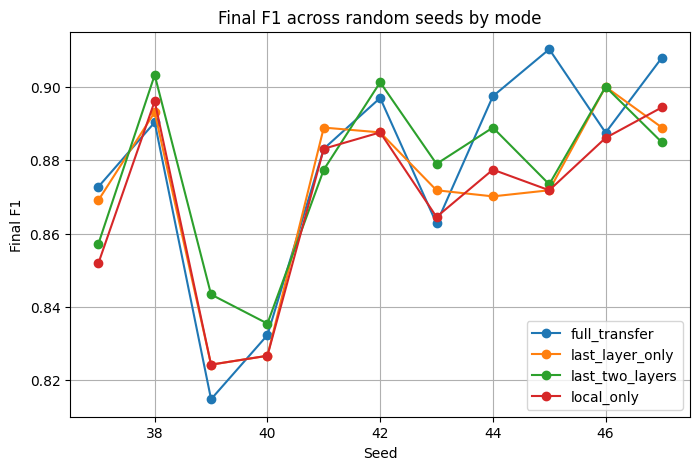

In [18]:
plt.figure(figsize=(8, 5))
for mode in final_results_df["mode"].unique():
    subset = final_results_df[final_results_df["mode"] == mode]
    plt.plot(subset["seed"], subset["f1"], marker="o", label=mode)

plt.xlabel("Seed")
plt.ylabel("Final F1")
plt.title("Final F1 across random seeds by mode")
plt.legend()
plt.grid(True)
plt.show()

## 9. Short interpretation

The deeper MLP fixed the main limitation of the earlier experiment: it made it possible to test a real intermediate transfer strategy.

In the final multi-seed summary, `full_transfer` had the highest mean final F1 (0.8778), but `last_two_layers` was very close (0.8767). At the same time, `last_two_layers` used much less transfer cost on average than `full_transfer` (870 vs 1830).

That is the most useful result from this sprint. It suggests that transferring more than just the output layer may recover most of the benefit of full transfer without sending the whole model.

### Main takeaways

- the deeper architecture solved the earlier bottleneck
- `last_two_layers` is now a proper middle condition
- `last_two_layers` performed almost as well as `full_transfer`
- the main pattern is a trade-off between final performance and communication cost
- the result is promising, but still preliminary because the setup is small

### Limitations

This experiment should still be treated cautiously:

- only two clients are used
- the dataset is relatively small
- only one deeper architecture was tested
- results still vary by seed

So this notebook supports the proposal direction, but it does not settle the question.

In [19]:
all_results_df.to_csv("../results/two_client_seed_validation_all_rounds_deeper_nn.csv", index=False)
final_results_df.to_csv("../results/two_client_seed_validation_final_results_deeper_nn.csv", index=False)
summary_df.to_csv("../results/two_client_seed_validation_summary_deeper_nn.csv", index=False)

print("Saved seed-validation results to ../results/")

Saved seed-validation results to ../results/
